In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

rng = np.random.default_rng(42)

In [6]:
# ── Distribution parameters ──────────────────────────────────────────────────
N_DENSE   = 10
N_EACH    = 1_000_000
N_SPARSE  = 10
N_OUTLIER = 1_000_000
N_OUTLIER_PTS = 10
OUTLIER_POINT_SIZE = 4

# Coordinate space: roughly [-10, 10] x [-10, 10]
SPACE = 10.0

# Random means for the 10 dense classes
dense_means = rng.uniform(-SPACE * 0.8, SPACE * 0.8, size=(N_DENSE, 2))
dense_stds  = rng.uniform(0.3, 1.2, size=N_DENSE)

# Colors: 10 dense classes get a tab10 palette,
# sparse class = bright yellow, outlier class = bright magenta
tab10 = plt.get_cmap("tab10")
dense_colors   = [np.array(tab10(i)[:3]) for i in range(N_DENSE)]
sparse_color   = np.array([1.0, 0.9, 0.0])   # yellow
outlier_color  = np.array([1.0, 0.0, 1.0])   # magenta

# ── Generate point clouds ────────────────────────────────────────────────────
dense_points = []
for i in range(N_DENSE):
    pts = rng.normal(loc=dense_means[i], scale=dense_stds[i], size=(N_EACH, 2))
    dense_points.append(pts)

sparse_points = rng.uniform(-SPACE, SPACE, size=(N_SPARSE, 2))

outlier_main = rng.normal(loc=[2.0, -3.0], scale=1.0, size=(N_OUTLIER, 2))
outlier_pts  = rng.uniform(-SPACE * 0.9, SPACE * 0.9, size=(N_OUTLIER_PTS, 2))
outlier_points = np.vstack([outlier_main, outlier_pts])

# Collect all classes as (points, color, label)
all_classes = (
    [(dense_points[i], dense_colors[i], f"Dense {i}") for i in range(N_DENSE)]
    + [(sparse_points,  sparse_color,  "Sparse")]
    + [(outlier_points, outlier_color, "Outlier")]
)

print(f"Total classes: {len(all_classes)}")
print(f"Dense class sizes: {[len(p) for p,_,_ in all_classes[:10]]}")
print(f"Sparse size: {len(sparse_points)}, Outlier size: {len(outlier_points)}")

Total classes: 12
Dense class sizes: [1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000]
Sparse size: 10, Outlier size: 1000010


In [7]:
# ── Compute 2-D histograms ────────────────────────────────────────────────────
BINS = 200
BIN_RANGE = [[-SPACE, SPACE], [-SPACE, SPACE]]

hists   = []   # raw counts  (BINS x BINS)
colors  = []   # RGB arrays
labels  = []

for pts, col, lbl in all_classes:
    h, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=BINS, range=BIN_RANGE)
    hists.append(h)
    colors.append(col)
    labels.append(lbl)

hists  = np.array(hists)   # (n_classes, 200, 200)
colors = np.array(colors)  # (n_classes, 3)

# Log-normalised density per class (used by most visualisations)
def log_norm(h):
    """Map counts -> [0,1] via log1p, then normalise to max."""
    l = np.log1p(h)
    m = l.max()
    return l / m if m > 0 else l

log_hists = np.stack([log_norm(h) for h in hists])  # (n_classes, 200, 200)

print("Histogram stack shape:", hists.shape)
print("Max counts per class:", hists.max(axis=(1,2)))
OUTLIER_PERCENTILE = 10  # bottom X% of non-zero bins per class are flagged as outlier cells

Histogram stack shape: (12, 200, 200)
Max counts per class: [1.7280e+03 4.1840e+03 1.1970e+03 1.3570e+03 1.6500e+03 7.2680e+03
 3.1050e+03 1.3552e+04 8.3480e+03 1.9210e+03 1.0000e+00 1.6210e+03]


Visualisation 1: Additive Blending — black background (with outlier points)
    additive_blend    : 0.01s
    draw_outlier_points: 0.02s


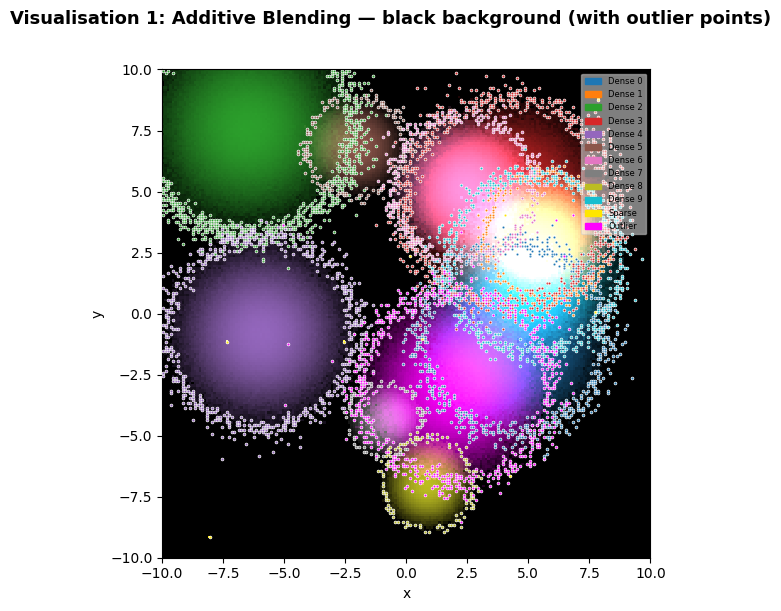

    render : 0.22s
Visualisation 1: Additive Blending — black background (without outlier points)
    additive_blend    : 0.01s


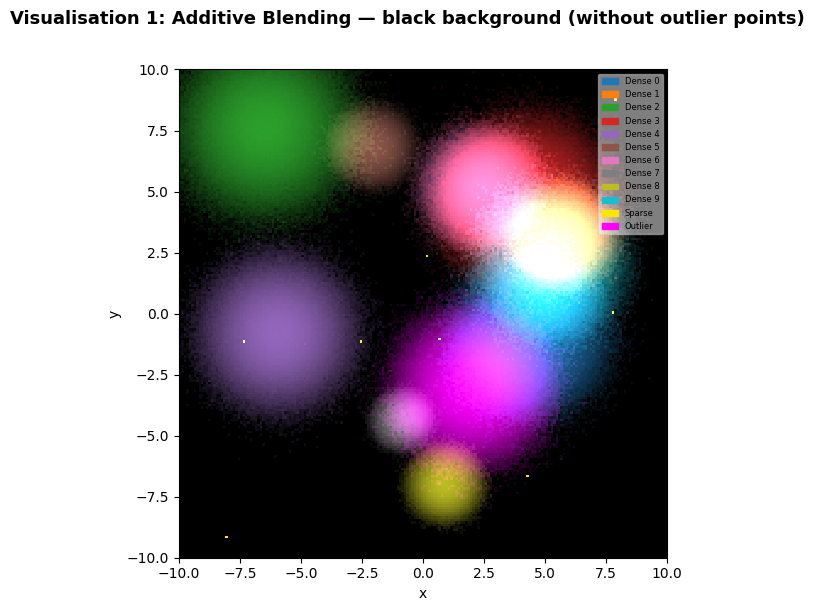

    render : 0.14s
Visualisation 2: Additive Blending — white background (with outlier points)
    additive_blend    : 0.01s
    draw_outlier_points: 0.02s


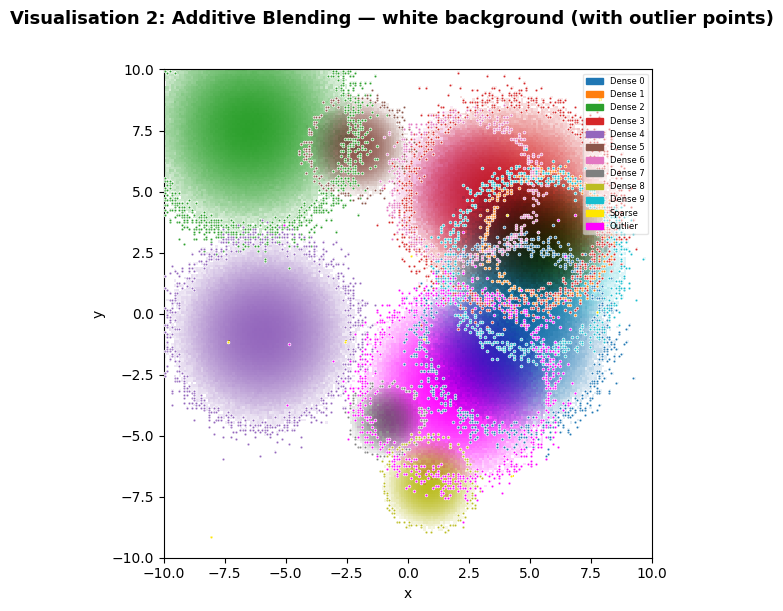

    render : 0.20s
Visualisation 2: Additive Blending — white background (without outlier points)
    additive_blend    : 0.01s


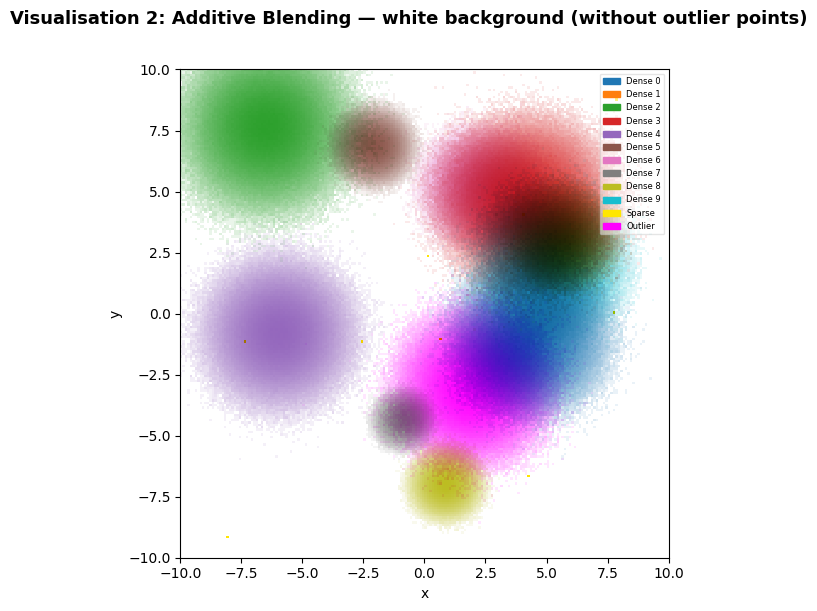

    render : 0.15s


In [8]:
# ── Helper: save / show figure ────────────────────────────────────────────────
def show(fig, title):
    t0 = time.perf_counter()
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"    render : {time.perf_counter() - t0:.2f}s")

def legend_patches(colors, labels):
    return [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]

# ── Helper: overlay outlier-cell scatter points ───────────────────────────────
def draw_outlier_points(ax, hists, cols, labels, bins=BINS, space=SPACE, percentile=OUTLIER_PERCENTILE):
    """
    For each class, find bins whose log-normalised count falls in the bottom
    `percentile`% of that class's non-zero bins.  Draw those bin centres as
    scatter points with class-colour fill and a white border.
    """
    bin_width = (2 * space) / bins
    # bin-centre coordinates
    centres = np.linspace(-space + bin_width / 2, space - bin_width / 2, bins)

    for i, (col, lbl) in enumerate(zip(cols, labels)):
        h = hists[i]                          # (bins_x, bins_y)  — histogram2d axes
        log_h = np.log1p(h)
        nonzero = log_h[log_h > 0]
        if nonzero.size == 0:
            continue
        threshold = np.percentile(nonzero, percentile)
        # mask: non-zero AND below threshold
        mask = (log_h > 0) & (log_h <= threshold)   # (bins_x, bins_y)
        xi, yi = np.where(mask)                      # indices in (x-bin, y-bin) space
        if xi.size == 0:
            continue
        xs = centres[xi]
        ys = centres[yi]
        ax.scatter(xs, ys, s=OUTLIER_POINT_SIZE, color=col, edgecolors="white",
                   linewidths=0.5, zorder=5, label=f"{lbl} outlier cells")

# ── Viz 1 & 2 : Additive colour blending ─────────────────────────────────────
def additive_blend(log_h, cols, background="black"):
    if background == "black":
        # Additive: sum density_i * color_i onto black canvas
        canvas = np.zeros((*log_h.shape[1:], 3), dtype=np.float64)
        for i in range(len(cols)):
            canvas += log_h[i, :, :, None] * cols[i]
        canvas = np.clip(canvas, 0, 1)
    else:
        # Subtractive on white: start at 1 and multiply down toward class color
        # Each class pulls the canvas toward its hue proportional to density
        canvas = np.ones((*log_h.shape[1:], 3), dtype=np.float64)
        for i in range(len(cols)):
            # density=0 → no change; density=1 → full class color
            canvas *= 1.0 - log_h[i, :, :, None] * (1.0 - cols[i])
        canvas = np.clip(canvas, 0, 1)

    return np.transpose(canvas, (1, 0, 2))

for bg in ["black", "white"]:
    for show_outliers in [True, False]:
        suffix = "with outlier points" if show_outliers else "without outlier points"
        viz_num = '1' if bg == 'black' else '2'
        title = f"Visualisation {viz_num}: Additive Blending — {bg} background ({suffix})"
        print(title)
        fig, ax = plt.subplots(figsize=(7, 6))

        t0 = time.perf_counter()
        img = additive_blend(log_hists, colors, background=bg)
        print(f"    additive_blend    : {time.perf_counter() - t0:.2f}s")

        ax.imshow(img, origin="lower", extent=[-SPACE, SPACE, -SPACE, SPACE],
                  interpolation="nearest")
        ax.set_facecolor(bg)

        if show_outliers:
            t0 = time.perf_counter()
            draw_outlier_points(ax, hists, colors, labels)
            print(f"    draw_outlier_points: {time.perf_counter() - t0:.2f}s")

        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=6, framealpha=0.5)
        show(fig, title)

Visualisation 3: Alpha-Based Blending — Viz 3 – Sparse on top (with outlier points)
    alpha_blend_ordered : 0.04s
    draw_outlier_points : 0.02s


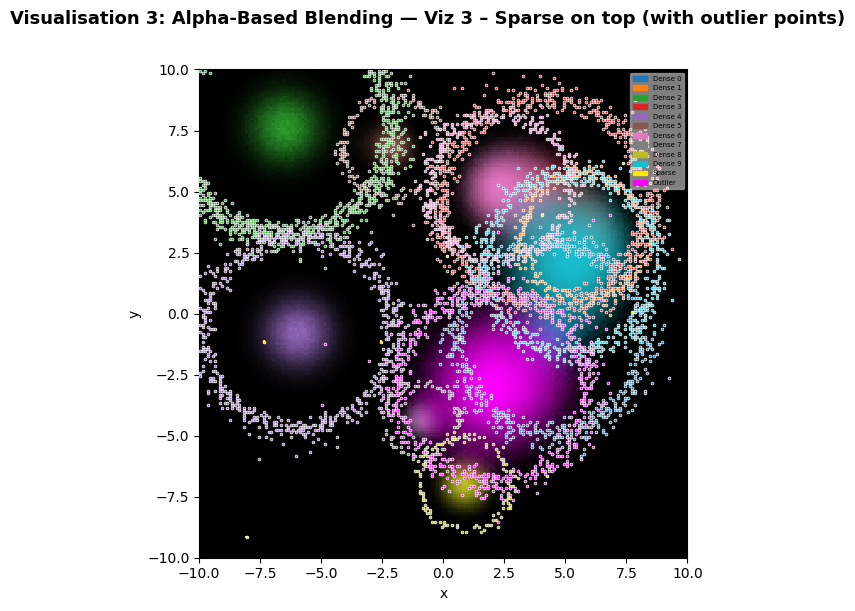

    render : 0.22s
Visualisation 3: Alpha-Based Blending — Viz 3 – Sparse on top (without outlier points)
    alpha_blend_ordered : 0.03s


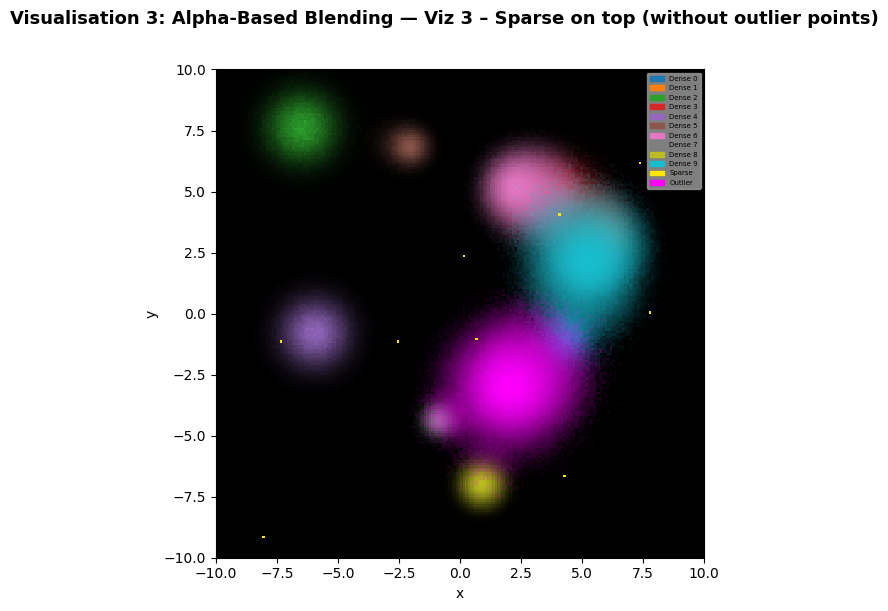

    render : 0.14s
Visualisation 4: Alpha-Based Blending — Viz 4 – Dense on top (with outlier points)
    alpha_blend_ordered : 0.03s
    draw_outlier_points : 0.02s


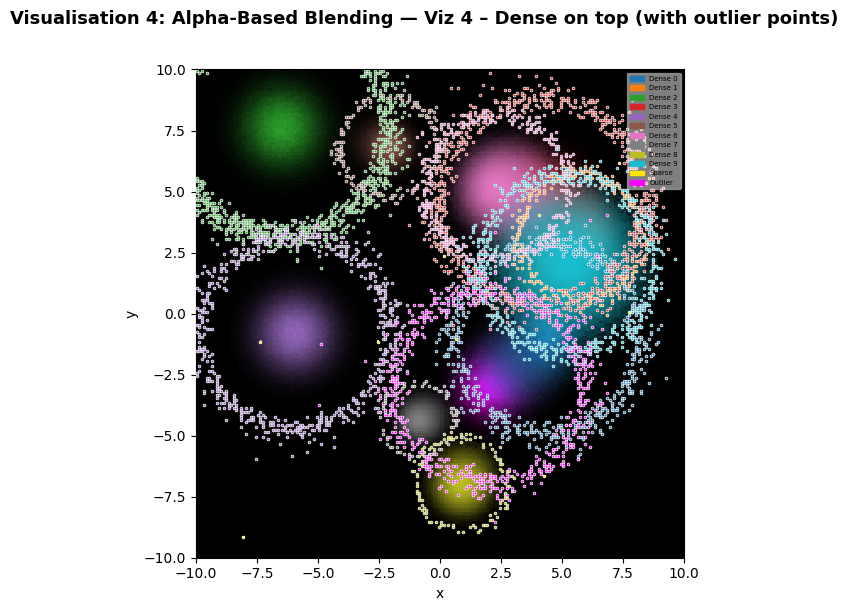

    render : 0.20s
Visualisation 4: Alpha-Based Blending — Viz 4 – Dense on top (without outlier points)
    alpha_blend_ordered : 0.03s


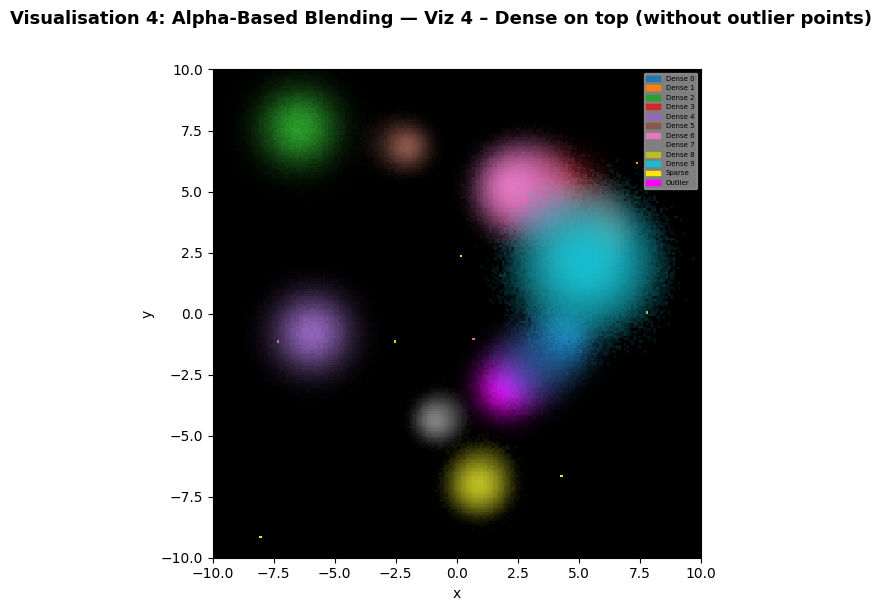

    render : 0.14s
Visualisation 5: Alpha-Based Blending — Viz 5 – Outlier on top (with outlier points)
    alpha_blend_ordered : 0.03s
    draw_outlier_points : 0.02s


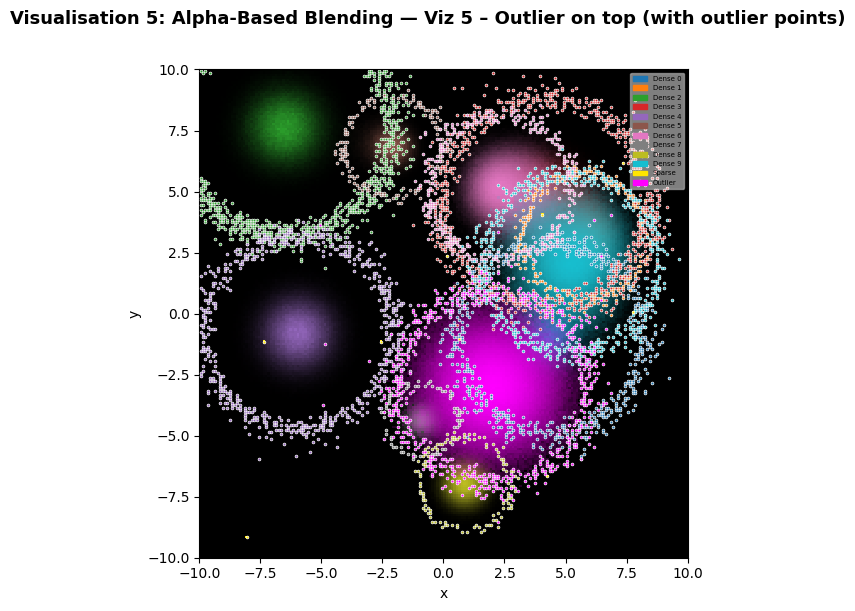

    render : 0.20s
Visualisation 5: Alpha-Based Blending — Viz 5 – Outlier on top (without outlier points)
    alpha_blend_ordered : 0.03s


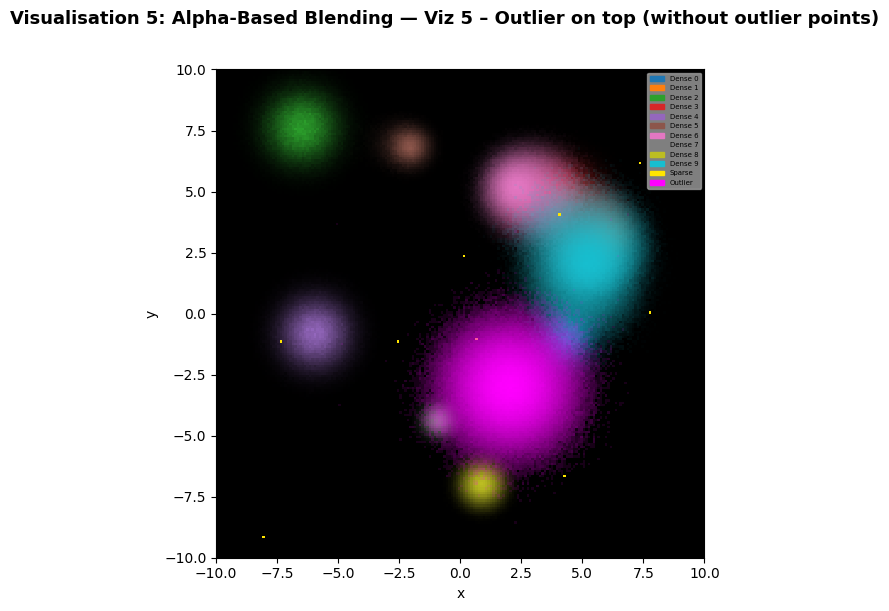

    render : 0.14s


In [9]:
# ── Viz 3–5 : Alpha-based blending (painter's algorithm) ─────────────────────
def alpha_blend_ordered(log_h, cols, order):
    """
    Render classes in `order` (back to front).
    Each class contributes RGBA where A = density value.
    """
    H, W = log_h.shape[1], log_h.shape[2]
    canvas = np.zeros((H, W, 4), dtype=np.float64)   # RGBA, starts transparent

    for idx in order:
        alpha = log_h[idx]                            # (H, W)
        src   = np.concatenate([cols[idx], [1.0]])    # RGBA source colour, opaque
        # Standard alpha compositing: dst = src*alpha + dst*(1-alpha)
        canvas[..., :3] = (
            src[:3] * alpha[:, :, None] * src[3]
            + canvas[..., :3] * canvas[..., 3:4] * (1 - alpha[:, :, None] * src[3])
        )
        canvas[..., 3] = (
            src[3] * alpha
            + canvas[..., 3] * (1 - src[3] * alpha)
        )

    rgb = np.clip(canvas[..., :3], 0, 1)
    return np.transpose(rgb, (1, 0, 2))

# Class index legend:
# 0-9  → dense classes
# 10   → sparse
# 11   → outlier

dense_idx   = list(range(10))
sparse_idx  = 10
outlier_idx = 11

orders = {
    "Viz 3 – Sparse on top":  dense_idx + [outlier_idx, sparse_idx],
    "Viz 4 – Dense on top":   [sparse_idx, outlier_idx] + dense_idx,
    "Viz 5 – Outlier on top": dense_idx + [sparse_idx, outlier_idx],
}

for i, (title_key, order) in enumerate(orders.items(), start=3):
    for show_outliers in [True, False]:
        suffix = "with outlier points" if show_outliers else "without outlier points"
        title = f"Visualisation {i}: Alpha-Based Blending — {title_key} ({suffix})"
        print(title)
        fig, ax = plt.subplots(figsize=(7, 6))

        t0 = time.perf_counter()
        img = alpha_blend_ordered(log_hists, colors, order)
        print(f"    alpha_blend_ordered : {time.perf_counter() - t0:.2f}s")

        ax.imshow(img, origin="lower", extent=[-SPACE, SPACE, -SPACE, SPACE],
                  interpolation="nearest")

        if show_outliers:
            t0 = time.perf_counter()
            draw_outlier_points(ax, hists, colors, labels)
            print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=5, framealpha=0.5)
        show(fig, title)

subdivided_pixel: 0.02s
Visualisation 6: Subdivided Pixel (with outlier points)
    draw_outlier_points : 0.02s


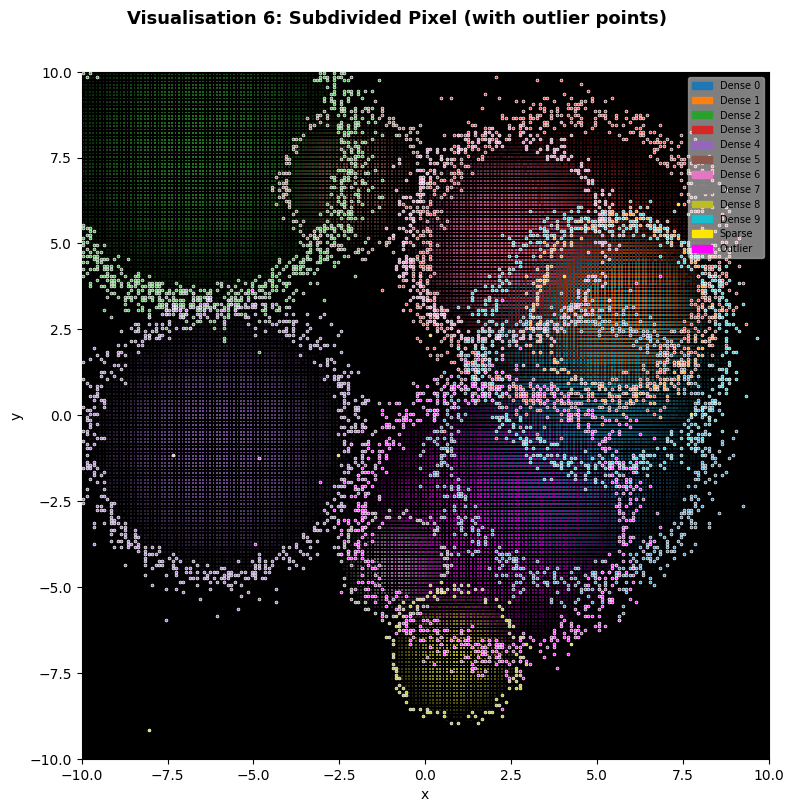

    render : 0.53s
Visualisation 6: Subdivided Pixel (without outlier points)


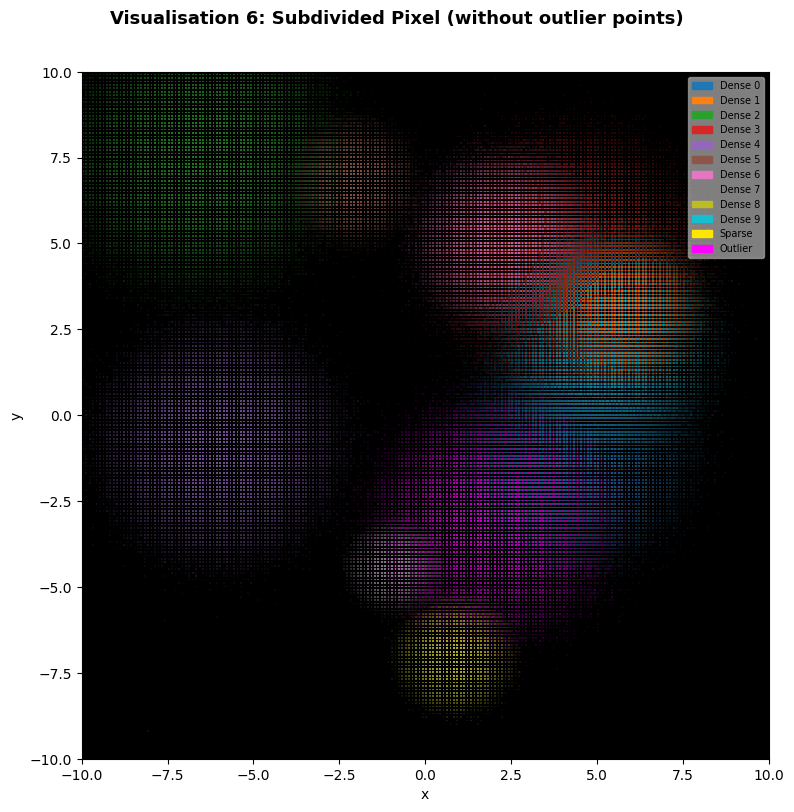

    render : 0.31s


In [10]:
# ── Viz 6 : Subdivided pixel (2×2 sub-pixels, top-4 classes per bin) ─────────
def subdivided_pixel(hists, cols, bins=BINS):
    """
    Each bin is rendered as a 2×2 block of sub-pixels.
    The 4 sub-pixels show the colours of the top-4 classes by raw count.
    Brightness of each sub-pixel is scaled by the log-normalised density
    of that ranked class (relative to the global max), so denser bins
    appear brighter.
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx = np.transpose(hists, (0, 2, 1))        # (n_classes, bins_y, bins_x)
    ranked = np.argsort(-h_yx, axis=0)            # (n_classes, bins_y, bins_x)

    # Log-normalise counts globally so brightness is comparable across ranks
    log_h = np.log1p(h_yx)
    global_max = log_h.max() + 1e-12
    log_h_norm = log_h / global_max              # (n_classes, bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        class_idx = ranked[rank]                  # (bins_y, bins_x)
        # brightness = log-normalised density of this rank's class
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]                                      # (bins_y, bins_x)
        pixel_colors = cols[class_idx] * brightness[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out

t0 = time.perf_counter()
img6 = subdivided_pixel(hists, colors)
print(f"subdivided_pixel: {time.perf_counter() - t0:.2f}s")

for show_outliers in [True, False]:
    suffix = "with outlier points" if show_outliers else "without outlier points"
    title = f"Visualisation 6: Subdivided Pixel ({suffix})"
    print(title)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img6, origin="lower", interpolation="nearest",
              extent=[-SPACE, SPACE, -SPACE, SPACE])
    ax.set_facecolor("black")

    if show_outliers:
        t0 = time.perf_counter()
        draw_outlier_points(ax, hists, colors, labels)
        print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(handles=legend_patches(colors, labels),
              loc="upper right", fontsize=7, framealpha=0.5)
    show(fig, title)

subdivided_pixel_filled: 0.03s
Visualisation 6b: Subdivided Pixel — Uncontested Fill (with outlier points)
    draw_outlier_points : 0.02s


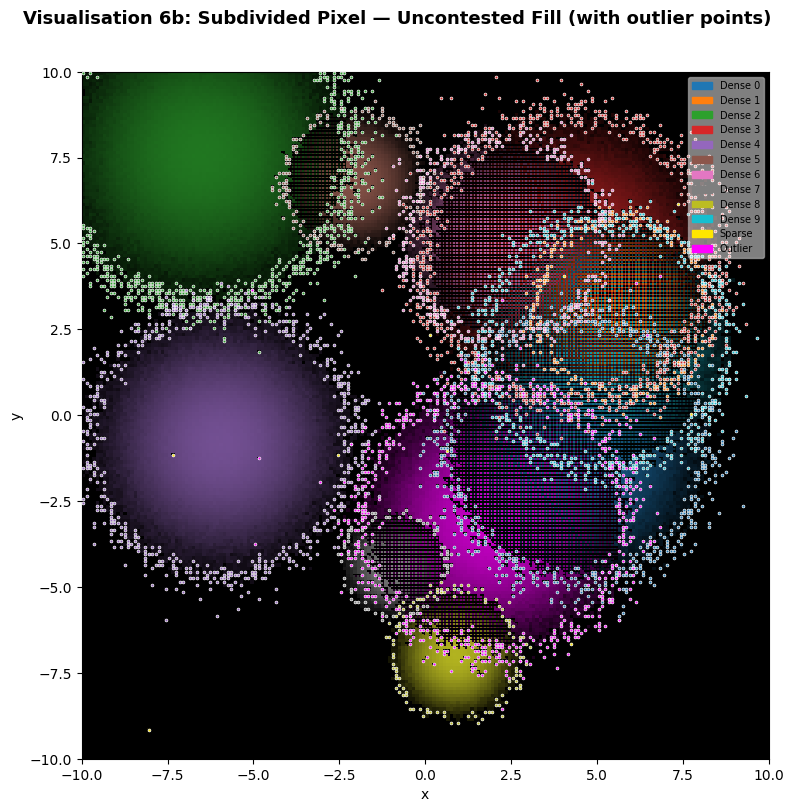

    render : 0.42s
Visualisation 6b: Subdivided Pixel — Uncontested Fill (without outlier points)


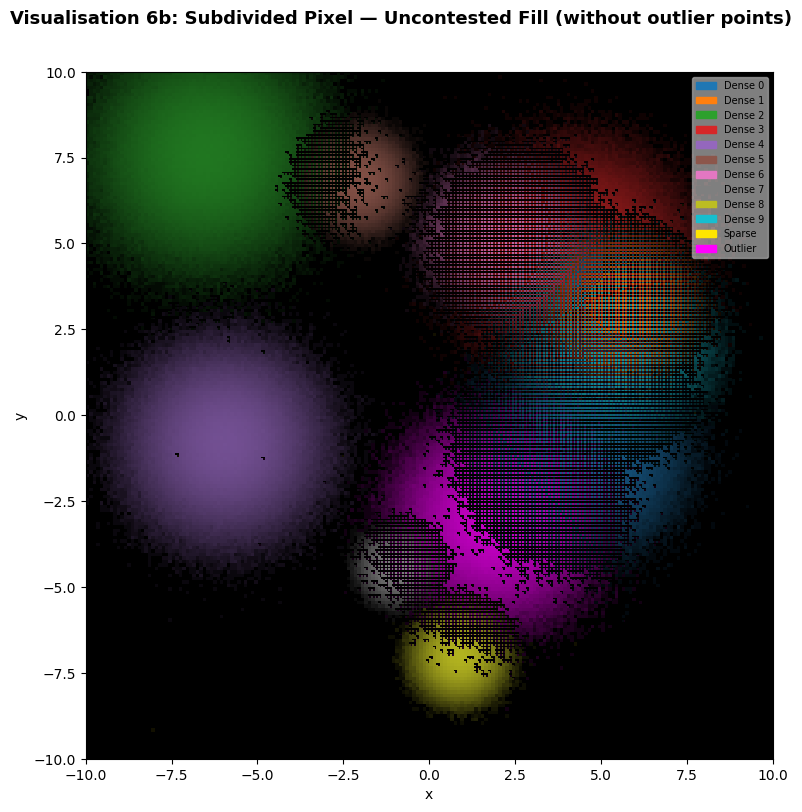

    render : 0.44s


In [11]:

# ── Viz 6b: Subdivided pixel — uncontested bins fill all 4 sub-pixels ────────
def subdivided_pixel_filled(hists, cols, bins=BINS):
    """
    2×2 sub-pixel layout with a contest-aware fill rule:

    • Uncontested bin  (exactly 1 class present): all 4 sub-pixels receive the
      dominant class colour at its brightness — the bin appears as a solid,
      fully-saturated block.
    • Contested bin    (2+ classes present): each sub-pixel shows its ranked
      class as in Viz 6.  Sub-pixels whose ranked class has zero count stay
      black (no dominant fill), so only the actually-present classes are shown.
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx = np.transpose(hists, (0, 2, 1))          # (n_classes, bins_y, bins_x)
    ranked = np.argsort(-h_yx, axis=0)              # (n_classes, bins_y, bins_x)

    log_h = np.log1p(h_yx)
    global_max = log_h.max() + 1e-12
    log_h_norm = log_h / global_max                 # (n_classes, bins_y, bins_x)

    # Number of classes with non-zero count per bin
    n_present = (h_yx > 0).sum(axis=0)             # (bins_y, bins_x)
    uncontested = n_present == 1                    # True where only 1 class present

    # Dominant class (rank 0) — used to fill all sub-pixels in uncontested bins
    dominant_idx = ranked[0]                        # (bins_y, bins_x)
    dominant_brightness = np.take_along_axis(
        log_h_norm, ranked[0:1], axis=0
    )[0]                                            # (bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]                                        # (bins_y, bins_x)
        class_idx = ranked[rank]                    # (bins_y, bins_x)

        # Uncontested bins → always use dominant class for every sub-pixel
        fill_idx    = np.where(uncontested, dominant_idx,        class_idx)
        fill_bright = np.where(uncontested, dominant_brightness, brightness)

        pixel_colors = cols[fill_idx] * fill_bright[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out

t0 = time.perf_counter()
img6b = subdivided_pixel_filled(hists, colors)
print(f"subdivided_pixel_filled: {time.perf_counter() - t0:.2f}s")

for show_outliers in [True, False]:
    suffix = "with outlier points" if show_outliers else "without outlier points"
    title = f"Visualisation 6b: Subdivided Pixel — Uncontested Fill ({suffix})"
    print(title)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img6b, origin="lower", interpolation="nearest",
              extent=[-SPACE, SPACE, -SPACE, SPACE])
    ax.set_facecolor("black")

    if show_outliers:
        t0 = time.perf_counter()
        draw_outlier_points(ax, hists, colors, labels)
        print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(handles=legend_patches(colors, labels),
              loc="upper right", fontsize=7, framealpha=0.5)
    show(fig, title)


subdivided_pixel_class_norm:        0.03s
subdivided_pixel_filled_class_norm: 0.03s
Visualisation 6c: Subdivided Pixel — Class-Normalised (with outlier points)
    draw_outlier_points : 0.02s


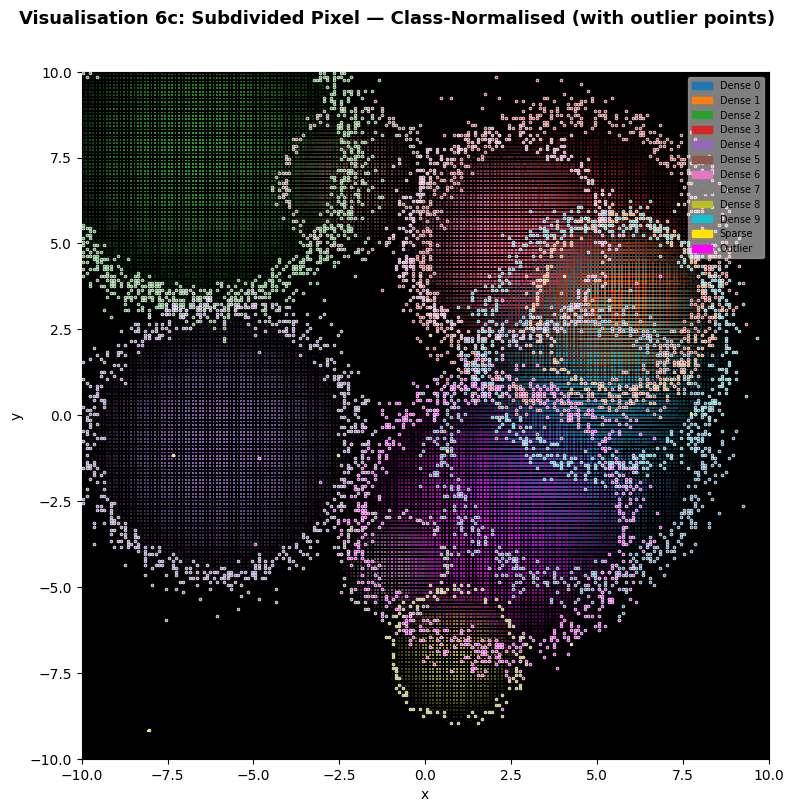

    render : 0.25s
Visualisation 6c: Subdivided Pixel — Class-Normalised (without outlier points)


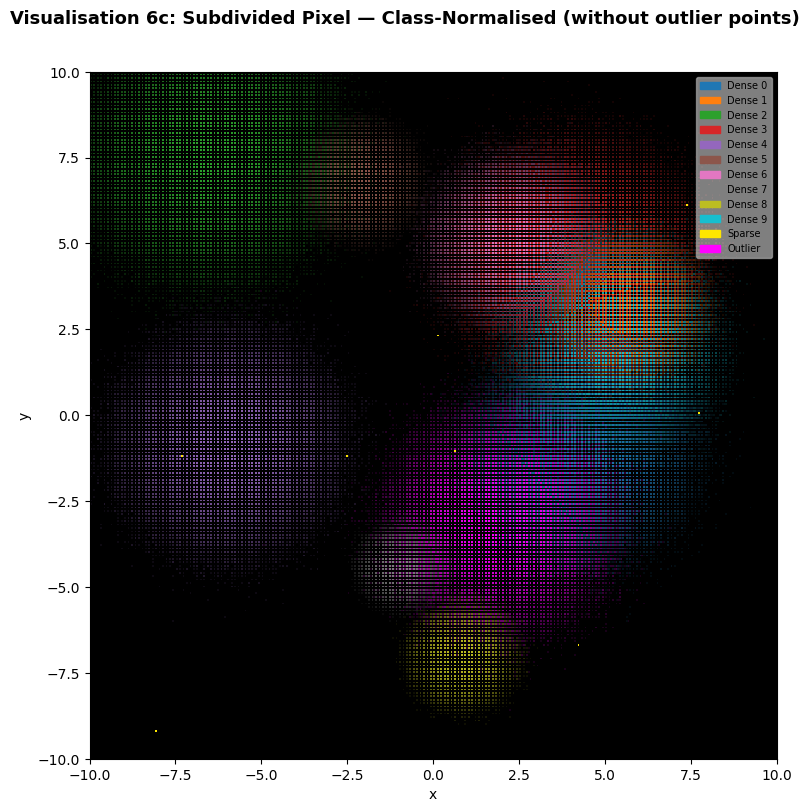

    render : 0.19s
Visualisation 6d: Subdivided Pixel — Class-Normalised + Uncontested Fill (with outlier points)
    draw_outlier_points : 0.02s


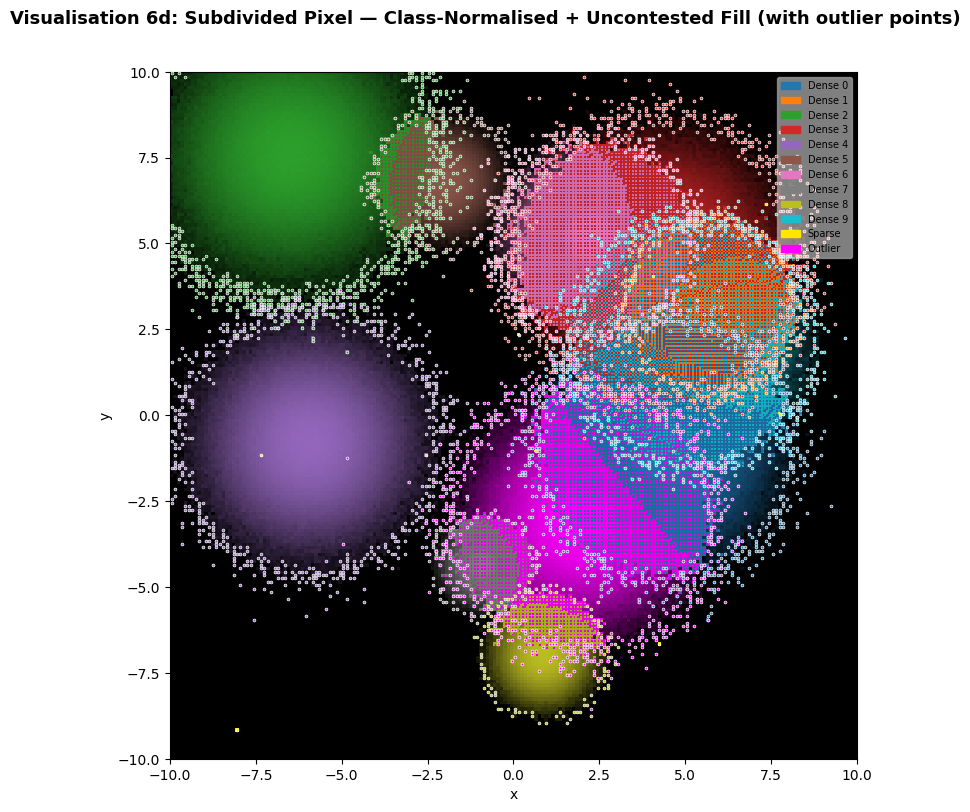

    render : 0.40s
Visualisation 6d: Subdivided Pixel — Class-Normalised + Uncontested Fill (without outlier points)


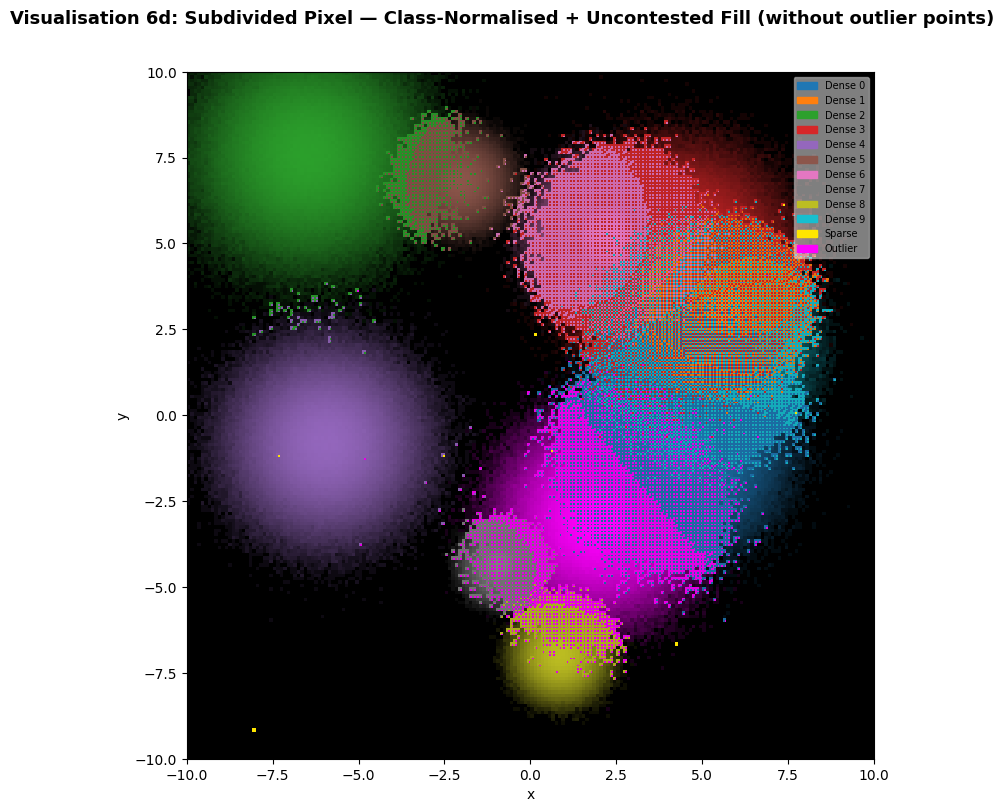

    render : 0.29s


In [12]:

# ── Viz 6c / 6d : Subdivided pixel — brightness normalised per class ──────────
def subdivided_pixel_class_norm(hists, cols, bins=BINS):
    """
    Like Viz 6 but brightness of each sub-pixel is normalised *within* the
    class that occupies it (per-class max = 1.0).

    This makes rare / sparse classes visible at full brightness in the bins
    where they do appear, instead of being dimmed by the global maximum which
    is dominated by the densest class.
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx = np.transpose(hists, (0, 2, 1))              # (n_classes, bins_y, bins_x)
    ranked = np.argsort(-h_yx, axis=0)                  # (n_classes, bins_y, bins_x)

    # Per-class log-normalised counts: each class's own maximum → 1.0
    log_h = np.log1p(h_yx)                              # (n_classes, bins_y, bins_x)
    class_max = log_h.max(axis=(1, 2), keepdims=True) + 1e-12
    log_h_norm = log_h / class_max                      # (n_classes, bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        class_idx  = ranked[rank]                        # (bins_y, bins_x)
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]                                             # (bins_y, bins_x)
        pixel_colors = cols[class_idx] * brightness[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out


def subdivided_pixel_filled_class_norm(hists, cols, bins=BINS, min_brightness=0.9):
    """
    Like Viz 6b (uncontested-fill rule) but brightness is normalised per class.
    Uncontested bins still fill all 4 sub-pixels with the dominant class colour,
    but the brightness is drawn from that class's own normalised range.

    In contested bins, a minimum brightness floor (`min_brightness`) is applied
    so lower-ranked classes remain visible rather than fading to near-black.
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx = np.transpose(hists, (0, 2, 1))
    ranked = np.argsort(-h_yx, axis=0)

    log_h = np.log1p(h_yx)
    class_max = log_h.max(axis=(1, 2), keepdims=True) + 1e-12
    log_h_norm = log_h / class_max                      # per-class normalised

    n_present   = (h_yx > 0).sum(axis=0)               # (bins_y, bins_x)
    uncontested = n_present == 1                    # True where only 1 class present
    contested   = n_present > 1                         # strictly more than 1 class

    dominant_idx = ranked[0]                            # (bins_y, bins_x)
    dominant_brightness = np.take_along_axis(
        log_h_norm, ranked[0:1], axis=0
    )[0]                                                # (bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]
        class_idx = ranked[rank]

        # For contested bins, redirect empty slots to the dominant class
        has_count = np.take_along_axis(h_yx > 0, ranked[rank:rank+1], axis=0)[0]
        use_dominant = uncontested | (contested & ~has_count)

        fill_idx    = np.where(use_dominant, dominant_idx,        class_idx)
        fill_bright = np.where(use_dominant, dominant_brightness, brightness)

        # Apply minimum brightness floor to all sub-pixels in contested bins
        fill_bright = np.where(contested, np.maximum(fill_bright, min_brightness), fill_bright)

        pixel_colors = cols[fill_idx] * fill_bright[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out


t0 = time.perf_counter()
img6c = subdivided_pixel_class_norm(hists, colors)
print(f"subdivided_pixel_class_norm:        {time.perf_counter() - t0:.2f}s")

t0 = time.perf_counter()
img6d = subdivided_pixel_filled_class_norm(hists, colors)
print(f"subdivided_pixel_filled_class_norm: {time.perf_counter() - t0:.2f}s")

for img, viz_id, desc in [
    (img6c, "6c", "Class-Normalised"),
    (img6d, "6d", "Class-Normalised + Uncontested Fill"),
]:
    for show_outliers in [True, False]:
        suffix = "with outlier points" if show_outliers else "without outlier points"
        title = f"Visualisation {viz_id}: Subdivided Pixel — {desc} ({suffix})"
        print(title)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img, origin="lower", interpolation="nearest",
                  extent=[-SPACE, SPACE, -SPACE, SPACE])
        ax.set_facecolor("black")

        if show_outliers:
            t0 = time.perf_counter()
            draw_outlier_points(ax, hists, colors, labels)
            print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=7, framealpha=0.5)
        show(fig, title)


subdivided_pixel_dominant_fill (global norm): 0.02s
subdivided_pixel_dominant_fill (class norm) : 0.02s
Visualisation 6e: Subdivided Pixel — Dominant Fill, Global-Norm (with outlier points)
    draw_outlier_points : 0.02s


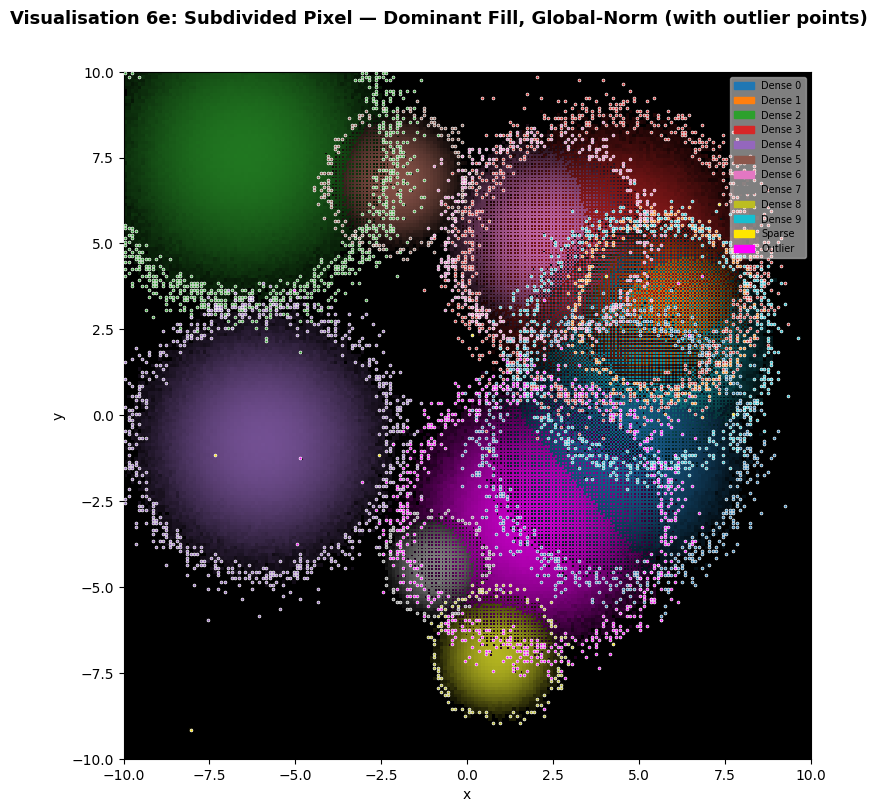

    render : 0.39s
Visualisation 6e: Subdivided Pixel — Dominant Fill, Global-Norm (without outlier points)


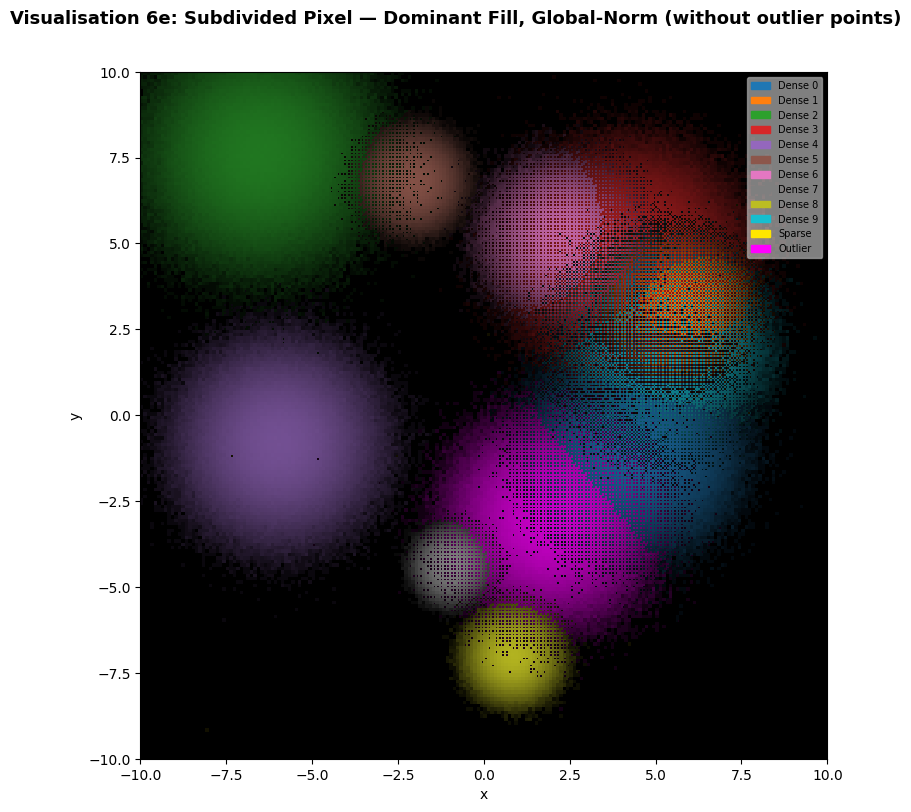

    render : 0.35s
Visualisation 6f: Subdivided Pixel — Dominant Fill, Class-Norm (with outlier points)
    draw_outlier_points : 0.02s


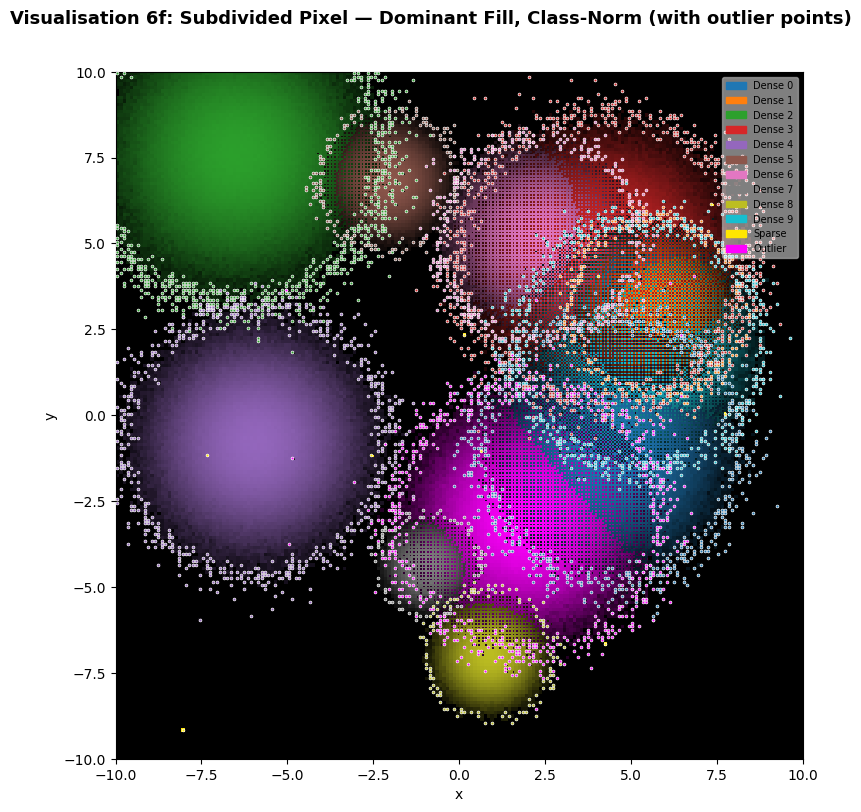

    render : 0.36s
Visualisation 6f: Subdivided Pixel — Dominant Fill, Class-Norm (without outlier points)


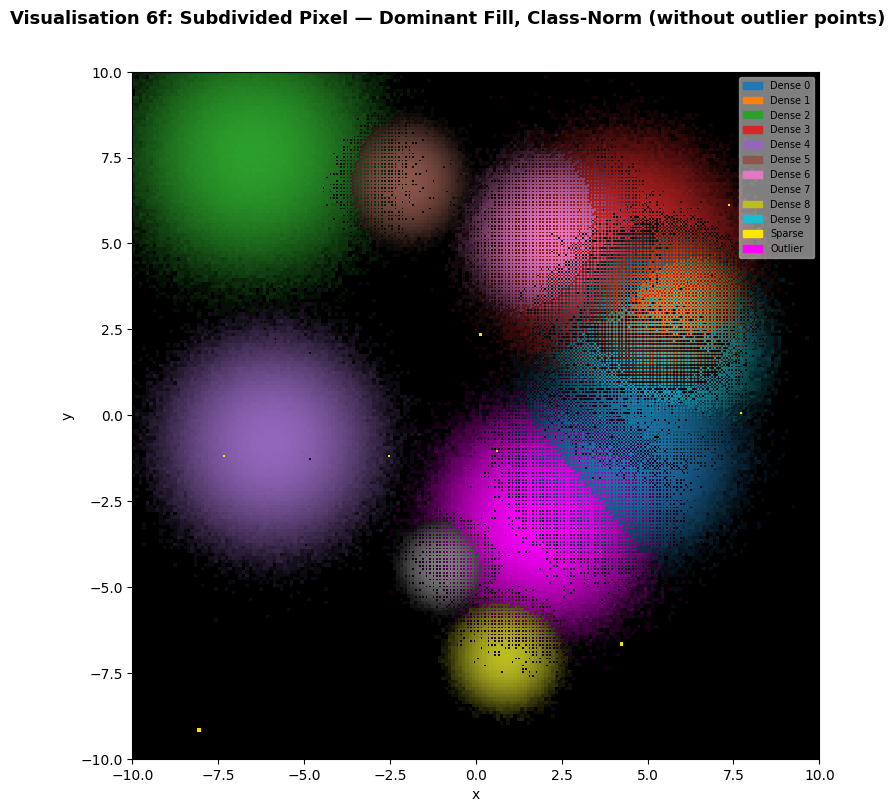

    render : 0.32s


In [13]:

# ── Viz 6e / 6f : Subdivided pixel — dominant class claims empty sub-pixels ──
#
# In a *contested* bin the 4 sub-pixel slots are ranked by count as usual, but
# any slot whose assigned class has zero count is reassigned to the rank-0
# (highest-count) class instead of staying black.  This lets the dominant class
# "spread" into the unused slots proportionally to how many competitors are
# absent, making its local weight visually obvious even at the sub-pixel level.
#
#   n classes present │ rank-0 sub-pixels │ rank-1 │ rank-2 │ rank-3
#   ──────────────────┼───────────────────┼────────┼────────┼────────
#          1          │        4  (all)   │   –    │   –    │   –
#          2          │        3          │   1    │   –    │   –
#          3          │        2          │   1    │   1    │   –
#         4+          │        1          │   1    │   1    │   1
#
# Viz 6e: global brightness normalisation (comparable to Viz 6 / 6b)
# Viz 6f: per-class brightness normalisation (comparable to Viz 6c / 6d)

def subdivided_pixel_dominant_fill(hists, cols, bins=BINS, class_norm=False):
    """
    2×2 sub-pixel layout where the rank-0 class claims any slot whose
    assigned class has zero count.  Uncontested bins (exactly 1 class present)
    fill all 4 sub-pixels with the dominant class.  In contested bins, any
    rank whose class has zero count also falls back to the dominant class.

    Parameters
    ----------
    class_norm : bool
        False → brightness normalised against the global maximum (like Viz 6).
        True  → brightness normalised per class (like Viz 6c).
    """
    sub = 2
    out = np.zeros((bins * sub, bins * sub, 3), dtype=np.float64)

    h_yx   = np.transpose(hists, (0, 2, 1))        # (n_classes, bins_y, bins_x)
    ranked = np.argsort(-h_yx, axis=0)              # (n_classes, bins_y, bins_x)

    log_h = np.log1p(h_yx)
    if class_norm:
        denom = log_h.max(axis=(1, 2), keepdims=True) + 1e-12
    else:
        denom = log_h.max() + 1e-12
    log_h_norm = log_h / denom                      # (n_classes, bins_y, bins_x)

    n_present   = (h_yx > 0).sum(axis=0)            # (bins_y, bins_x)
    uncontested = n_present <= 1                     # True where 0 or 1 class present

    # Rank-0 class and its brightness — used to fill empty sub-pixel slots
    dominant_idx = ranked[0]                         # (bins_y, bins_x)
    dominant_brightness = np.take_along_axis(
        log_h_norm, ranked[0:1], axis=0
    )[0]                                             # (bins_y, bins_x)

    sub_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for rank, (dr, dc) in enumerate(sub_positions):
        class_idx  = ranked[rank]                    # (bins_y, bins_x)
        brightness = np.take_along_axis(
            log_h_norm, ranked[rank:rank+1], axis=0
        )[0]                                         # (bins_y, bins_x)

        # Does the class assigned to this rank have any count in this bin?
        has_count = np.take_along_axis(
            h_yx > 0, ranked[rank:rank+1], axis=0
        )[0]                                         # (bins_y, bins_x)  bool

        # Uncontested bins OR empty slot → dominant class takes over
        use_dominant = uncontested | ~has_count
        fill_idx    = np.where(use_dominant, dominant_idx,        class_idx)
        fill_bright = np.where(use_dominant, dominant_brightness, brightness)

        pixel_colors = cols[fill_idx] * fill_bright[:, :, None]
        out[dr::sub, dc::sub] = pixel_colors

    return out


t0 = time.perf_counter()
img6e = subdivided_pixel_dominant_fill(hists, colors, class_norm=False)
print(f"subdivided_pixel_dominant_fill (global norm): {time.perf_counter() - t0:.2f}s")

t0 = time.perf_counter()
img6f = subdivided_pixel_dominant_fill(hists, colors, class_norm=True)
print(f"subdivided_pixel_dominant_fill (class norm) : {time.perf_counter() - t0:.2f}s")

for img, viz_id, norm_desc in [
    (img6e, "6e", "Global-Norm"),
    (img6f, "6f", "Class-Norm"),
]:
    for show_outliers in [True, False]:
        suffix = "with outlier points" if show_outliers else "without outlier points"
        title = f"Visualisation {viz_id}: Subdivided Pixel — Dominant Fill, {norm_desc} ({suffix})"
        print(title)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img, origin="lower", interpolation="nearest",
                  extent=[-SPACE, SPACE, -SPACE, SPACE])
        ax.set_facecolor("black")

        if show_outliers:
            t0 = time.perf_counter()
            draw_outlier_points(ax, hists, colors, labels)
            print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=7, framealpha=0.5)
        show(fig, title)


max_value_map: 0.00s
min_value_map: 0.00s
Visualisation 7: Colour Map — Max Value (with outlier points)
    draw_outlier_points : 0.02s


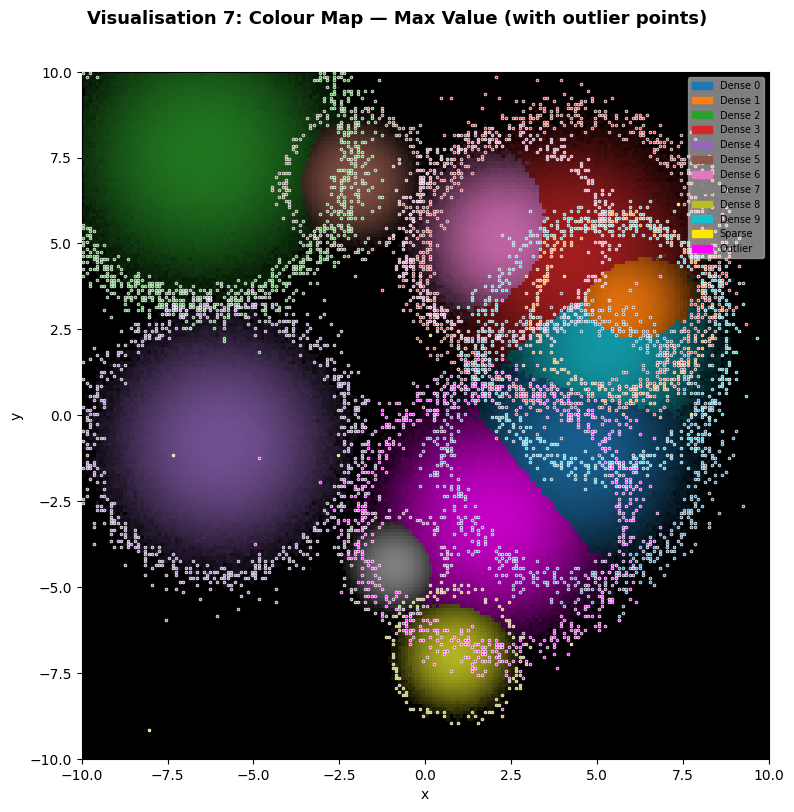

    render : 0.23s
Visualisation 7: Colour Map — Max Value (without outlier points)


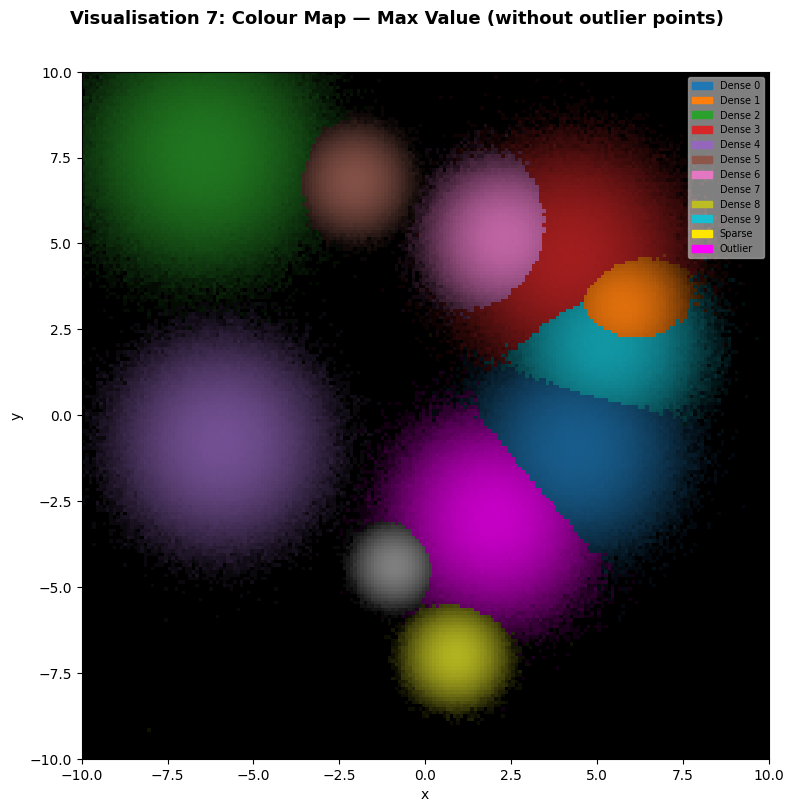

    render : 0.16s
Visualisation 7: Colour Map — Min Value (lowest count = bright) (with outlier points)
    draw_outlier_points : 0.02s


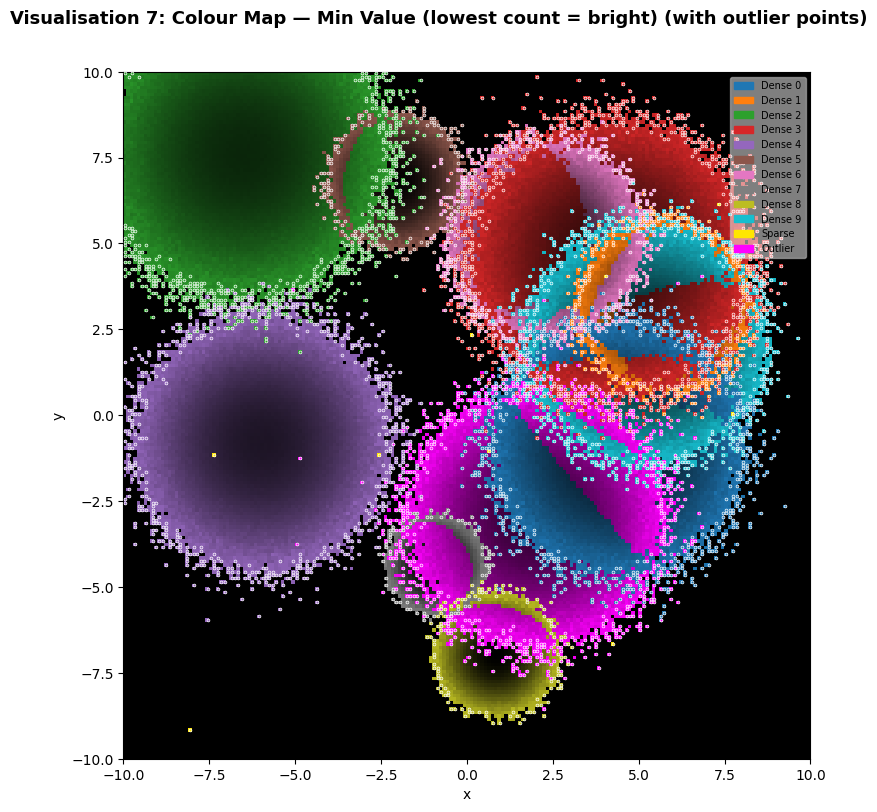

    render : 0.22s
Visualisation 7: Colour Map — Min Value (lowest count = bright) (without outlier points)


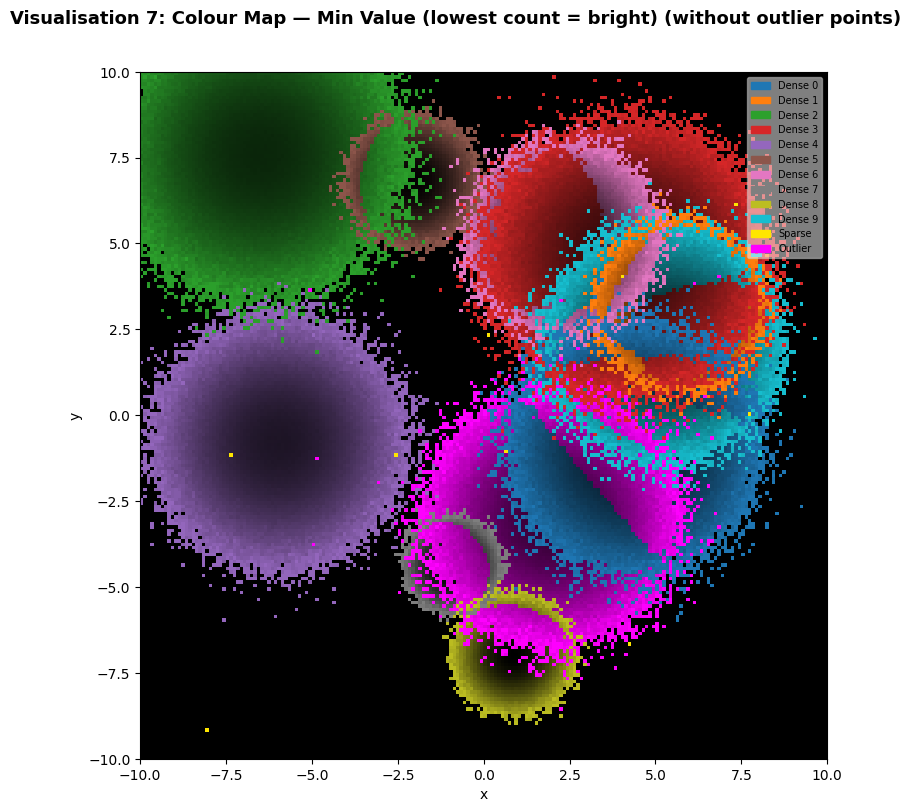

    render : 0.16s


In [14]:
# ── Viz 7 : Max-value / Min-value colouring ───────────────────────────────────
def max_value_map(hists, cols):
    """Each bin coloured by the class with the highest raw count."""
    winner = np.argmax(hists, axis=0)
    winner_h = hists[winner, np.arange(BINS)[:, None], np.arange(BINS)[None, :]]
    bright = np.log1p(winner_h)
    bright = bright / (bright.max() + 1e-12)
    img = cols[winner] * bright[:, :, None]
    return np.transpose(img, (1, 0, 2))

def min_value_map(hists, cols):
    """Each bin coloured by the class with the lowest non-zero raw count,
    with brightness inversely proportional to that count (lowest = brightest)."""
    hists_nonzero = np.where(hists > 0, hists, np.inf)
    winner = np.argmin(hists_nonzero, axis=0)
    winner_h = hists[winner, np.arange(BINS)[:, None], np.arange(BINS)[None, :]]
    any_nonzero = hists.max(axis=0) > 0

    # Invert: high log-count → low brightness, low log-count → high brightness
    log_w = np.log1p(winner_h)
    log_max = log_w[any_nonzero].max() if any_nonzero.any() else 1.0
    bright = np.where(any_nonzero, 1.0 - log_w / (log_max + 1e-12), 0.0)
    # Rescale so the brightest occupied bin = 1
    bmax = bright.max()
    bright = bright / (bmax + 1e-12)

    img = cols[winner] * bright[:, :, None]
    return np.transpose(img, (1, 0, 2))

t0 = time.perf_counter()
img7 = max_value_map(hists, colors)
print(f"max_value_map: {time.perf_counter() - t0:.2f}s")

t0 = time.perf_counter()
img7_inv = min_value_map(hists, colors)
print(f"min_value_map: {time.perf_counter() - t0:.2f}s")

for img, label in [(img7, "Max Value"), (img7_inv, "Min Value (lowest count = bright)")]:
    for show_outliers in [True, False]:
        suffix = "with outlier points" if show_outliers else "without outlier points"
        title = f"Visualisation 7: Colour Map — {label} ({suffix})"
        print(title)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img, origin="lower", interpolation="nearest",
                  extent=[-SPACE, SPACE, -SPACE, SPACE])
        ax.set_facecolor("black")

        if show_outliers:
            t0 = time.perf_counter()
            draw_outlier_points(ax, hists, colors, labels)
            print(f"    draw_outlier_points : {time.perf_counter() - t0:.2f}s")

        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.legend(handles=legend_patches(colors, labels),
                  loc="upper right", fontsize=7, framealpha=0.5)
        show(fig, title)

In [15]:

# ── Viz 8: 3-D KDE — per-class Gaussian-smoothed density surfaces ─────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 – activates 3-D projection

# Coarser grid for 3-D rendering: BINS=200 → VIS_BINS_3D=50 (factor=4)
VIS_BINS_3D = 50
factor_3d   = BINS // VIS_BINS_3D          # 4

coarse_hists_3d = (
    hists
    .reshape(len(all_classes), VIS_BINS_3D, factor_3d,
                                VIS_BINS_3D, factor_3d)
    .sum(axis=(2, 4))
)   # (n_classes, 50, 50)  — axis-0 = x, axis-1 = y (same convention as histogram2d)

# KDE ≈ Gaussian-smoothed coarse histogram, then log-normalised per class
KDE_SIGMA_3D = 3.0
kde_3d      = np.stack([gaussian_filter(h.astype(float), sigma=KDE_SIGMA_3D)
                        for h in coarse_hists_3d])
kde_3d_norm = np.stack([log_norm(k) for k in kde_3d])   # (n_classes, 50, 50)

# plot_surface coordinate grid
# histogram2d: axis-0 = x, axis-1 = y  →  surface Z must be transposed to (y, x)
# to match meshgrid's default (y-major) layout
bw3 = (2 * SPACE) / VIS_BINS_3D
cx3 = np.linspace(-SPACE + bw3 / 2, SPACE - bw3 / 2, VIS_BINS_3D)
X3, Y3 = np.meshgrid(cx3, cx3)   # both (50, 50); Y3 varies on axis-0, X3 on axis-1



Visualisation 9: 3-D Raw Histogram — default (elev=30°, azim=-60°)
    build_viz9 : 0.16s


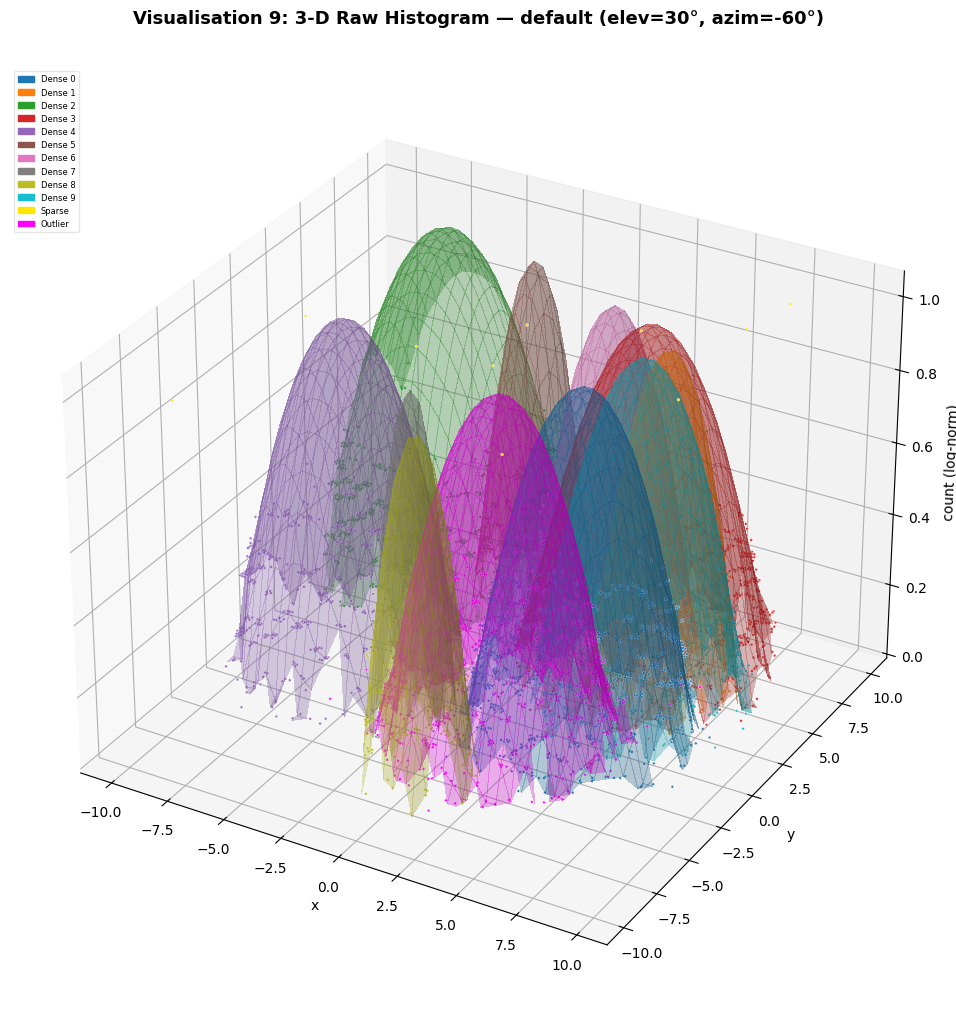

    render : 0.64s
Visualisation 9: 3-D Raw Histogram — high elevation (elev=60°, azim=-60°)
    build_viz9 : 0.16s


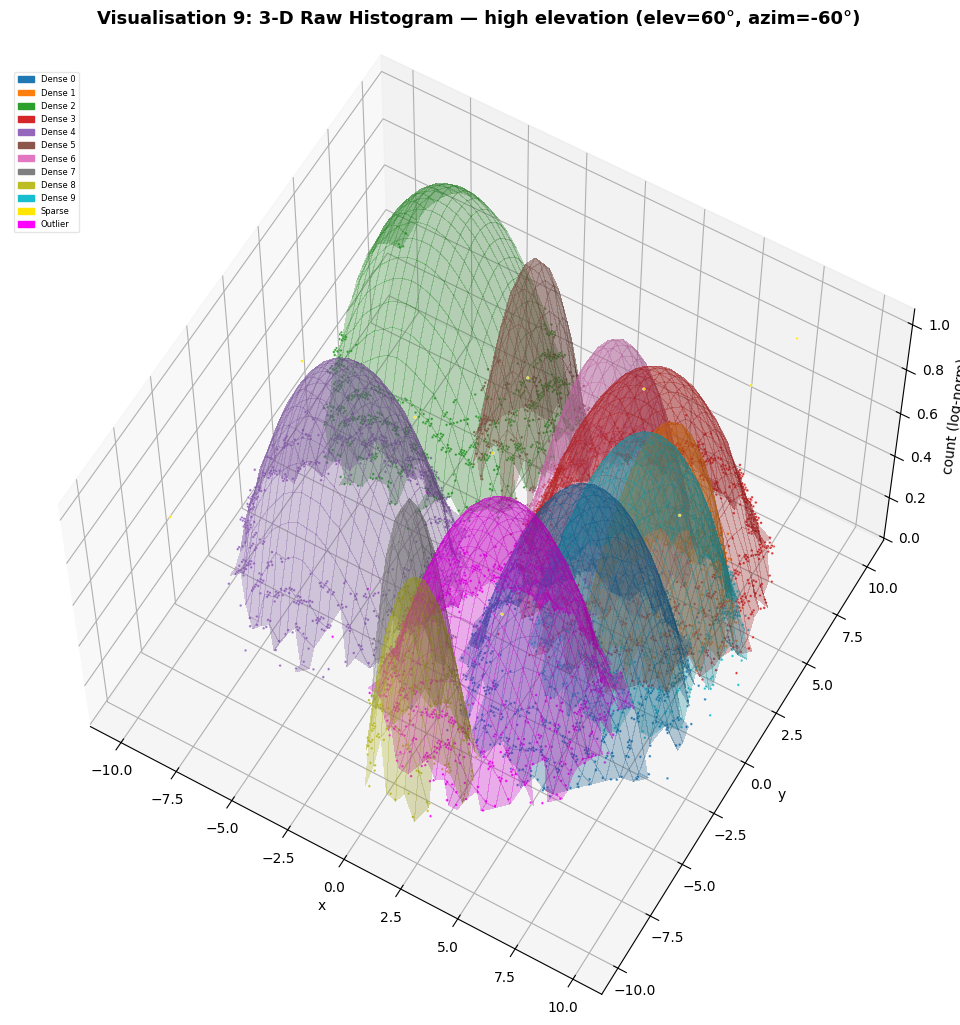

    render : 0.62s
Visualisation 9: 3-D Raw Histogram — low elevation (elev=10°, azim=-60°)
    build_viz9 : 0.16s


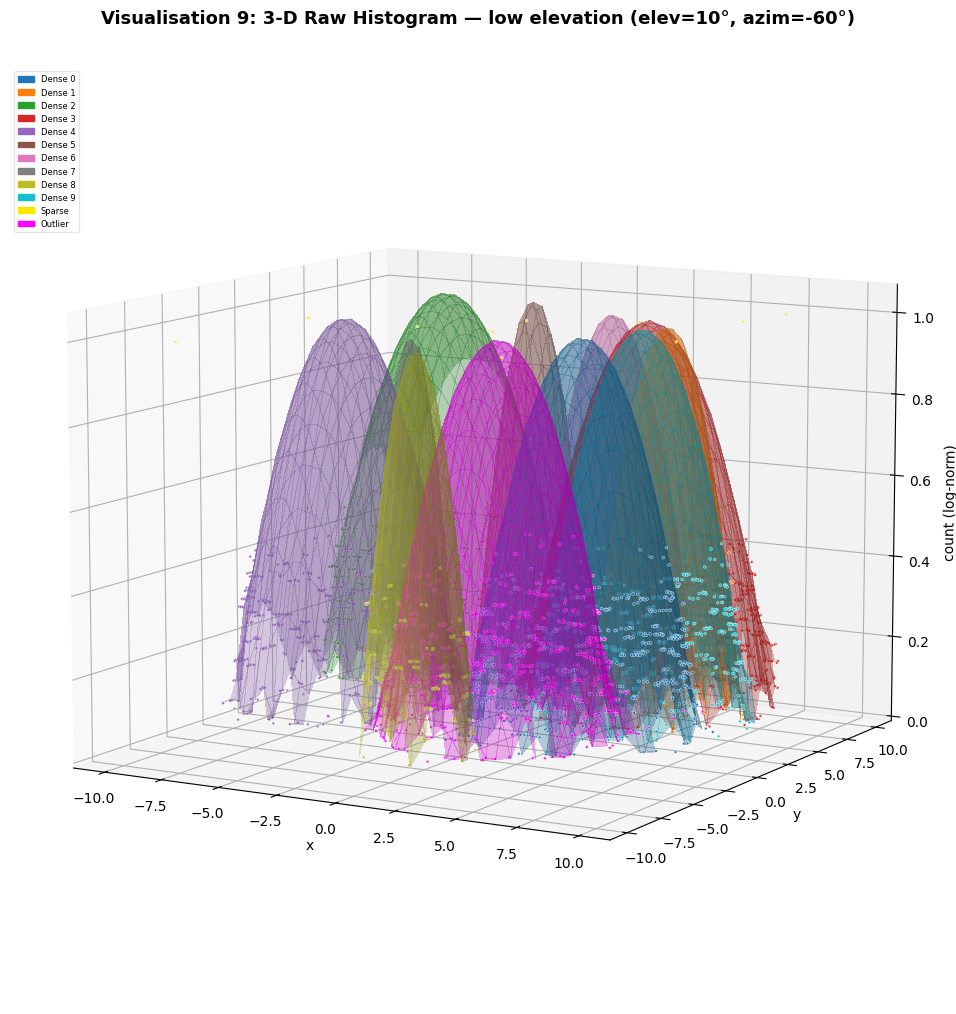

    render : 0.64s
Visualisation 9: 3-D Raw Histogram — side view (azim=0) (elev=30°, azim=0°)
    build_viz9 : 0.41s


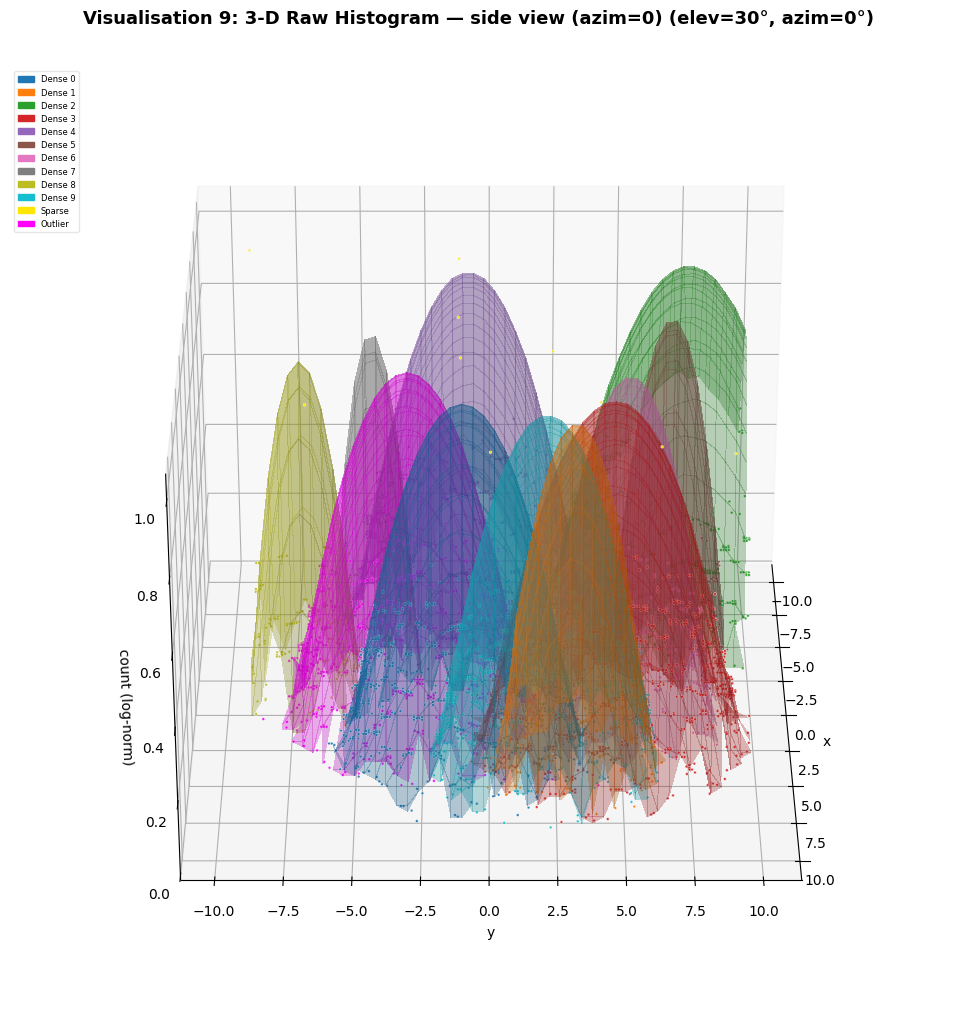

    render : 0.67s
Visualisation 9: 3-D Raw Histogram — top-down (elev=90°, azim=-90°)
    build_viz9 : 0.16s


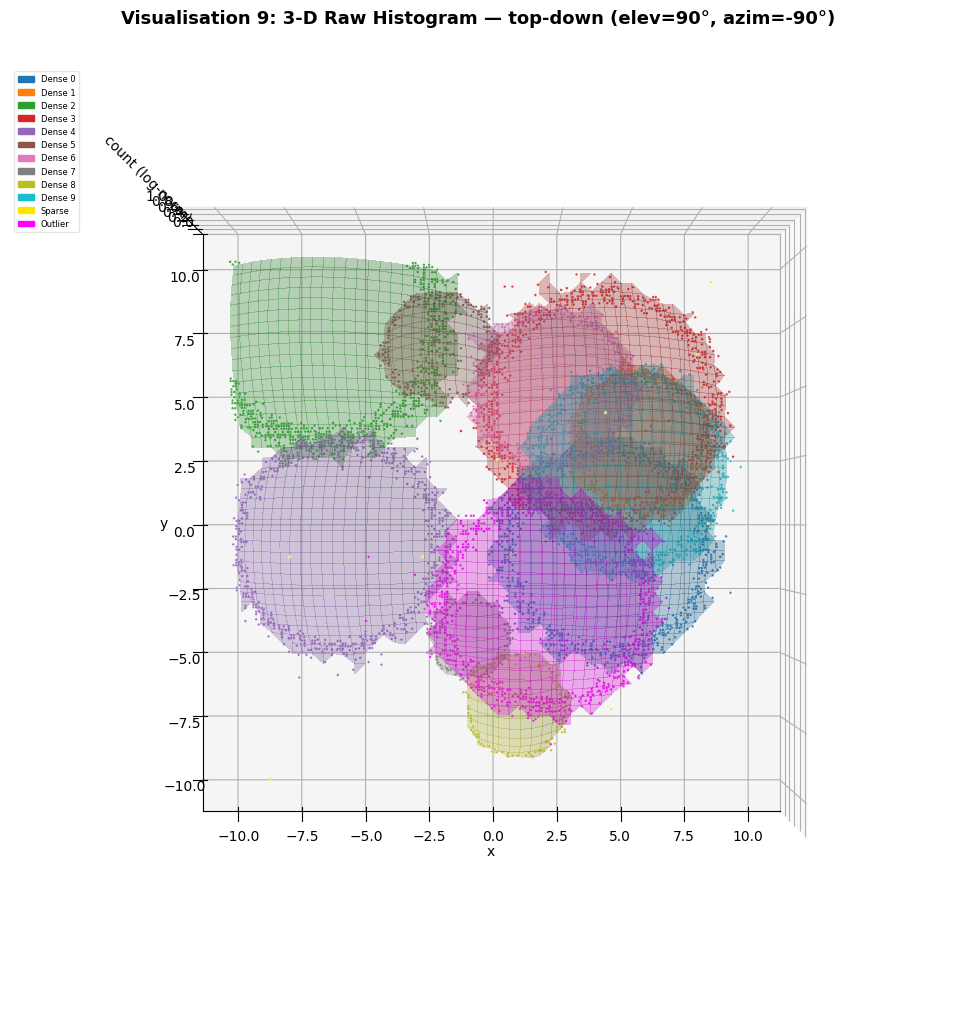

    render : 0.58s


In [16]:

# ── Viz 9: 3-D Raw Histogram — per-class log-normalised count surfaces ─────────
raw_3d_norm = np.stack([log_norm(h.astype(float)) for h in coarse_hists_3d])

def build_viz9(ax):
    for i, (col, lbl) in enumerate(zip(colors, labels)):
        Z_raw = raw_3d_norm[i].T
        Z = np.ma.masked_where(Z_raw == 0, Z_raw)
        ax.plot_surface(X3, Y3, Z, color=col, alpha=0.30,
                        linewidth=0, antialiased=False,
                        rcount=VIS_BINS_3D, ccount=VIS_BINS_3D)

        # Outlier points lifted onto the class surface
        h_fine = hists[i]
        log_h_fine = np.log1p(h_fine)
        nz = log_h_fine[log_h_fine > 0]
        if nz.size == 0:
            continue
        thr = np.percentile(nz, OUTLIER_PERCENTILE)
        mask = (log_h_fine > 0) & (log_h_fine <= thr)
        xi_fine, yi_fine = np.where(mask)
        xi_c = np.clip(xi_fine // factor_3d, 0, VIS_BINS_3D - 1)
        yi_c = np.clip(yi_fine // factor_3d, 0, VIS_BINS_3D - 1)
        bw_fine = (2 * SPACE) / BINS
        ctrs_fine = np.linspace(-SPACE + bw_fine / 2, SPACE - bw_fine / 2, BINS)
        xs, ys = ctrs_fine[xi_fine], ctrs_fine[yi_fine]
        zs = raw_3d_norm[i][xi_c, yi_c]
        ax.scatter(xs, ys, zs, s=OUTLIER_POINT_SIZE, color=col,
                   edgecolors="white", linewidths=0.3, alpha=0.9, zorder=5)

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("count (log-norm)")
    ax.legend(handles=legend_patches(colors, labels),
              loc="upper left", fontsize=6, framealpha=0.5)

# Viewing angles: (elev, azim, description)
view_angles = [
    (30,  -60,  "default"),
    (60,  -60,  "high elevation"),
    (10,  -60,  "low elevation"),
    (30,    0,  "side view (azim=0)"),
    (90,  -90,  "top-down"),
]

for elev, azim, desc in view_angles:
    title = f"Visualisation 9: 3-D Raw Histogram — {desc} (elev={elev}°, azim={azim}°)"
    print(title)
    fig = plt.figure(figsize=(13, 10))
    ax  = fig.add_subplot(111, projection="3d")

    t0 = time.perf_counter()
    build_viz9(ax)
    print(f"    build_viz9 : {time.perf_counter() - t0:.2f}s")

    ax.view_init(elev=elev, azim=azim)
    show(fig, title)